In [1]:
# =============================
# Import Libraries
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Full Model (Climate) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 5)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.756
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__C': 100.0}

Hold-out accuracy: 0.7538

Classification report:
              precision    recall  f1-score   support

        High     0.2857    0.0408    0.0714        98
         Low     0.8016    0.9391    0.8649      1183
      Medium     0.5249    0.3605    0.4275       380

    accuracy                         0.7538      1661
   macro avg     0.5374    0.4468    0.4546      1661
weighted avg     0.7079    0.7538    0.7180      1661



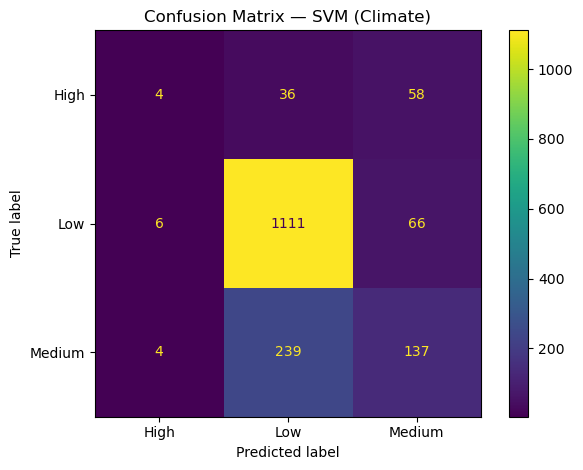

In [3]:
# ============================================================
# FULL MODEL: Climate
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = [
    "Rain",
    "Temperature",
    "Relative Humidity"
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + time)
numeric_cols = [
    "Rain",
    "Temperature",
    "Relative Humidity",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Climate) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Climate)")
plt.tight_layout()
plt.show()

Full Model (Socioeconomic) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7509
Best params: {'svm__kernel': 'poly', 'svm__gamma': 0.3593813663804626, 'svm__degree': 4, 'svm__C': 0.2395026619987486}

Hold-out accuracy: 0.7435

Classification report:
              precision    recall  f1-score   support

        High     0.5641    0.2245    0.3212        98
         Low     0.7709    0.9586    0.8546      1183
      Medium     0.5232    0.2079    0.2976       380

    accuracy                         0.7435      1661
   macro avg     0.6194    0.4637    0.4911      1661
weighted avg     0.7020    0.7435    0.6957      1661



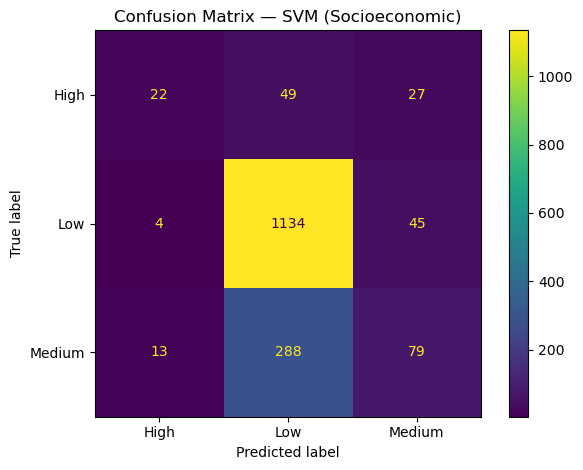

In [8]:
# ============================================================
# FULL MODEL: Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (socio + time)
numeric_cols = [
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Socioeconomic) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model (Environmental) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 11)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7527
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__C': 100.0}

Hold-out accuracy: 0.7706

Classification report:
              precision    recall  f1-score   support

        High     0.6111    0.2245    0.3284        98
         Low     0.8071    0.9552    0.8750      1183
      Medium     0.5689    0.3368    0.4231       380

    accuracy                         0.7706      1661
   macro avg     0.6624    0.5055    0.5422      1661
weighted avg     0.7411    0.7706    0.7393      1661



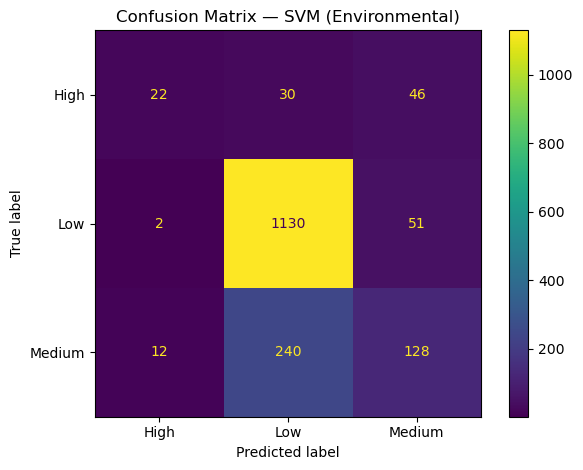

In [10]:
# ============================================================
# FULL MODEL: Environmental 
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (env numeric + time)
numeric_cols = [
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]
for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical environmental column
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Environmental) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,         
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Environmental)")
plt.tight_layout()
plt.show()

Full Model (Climate + Socioeconomic) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 17)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7566
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__C': 100.0}

Hold-out accuracy: 0.7538

Classification report:
              precision    recall  f1-score   support

        High     0.4423    0.2347    0.3067        98
         Low     0.8075    0.9256    0.8625      1183
      Medium     0.5296    0.3526    0.4234       380

    accuracy                         0.7538      1661
   macro avg     0.5932    0.5043    0.5309      1661
weighted avg     0.7224    0.7538    0.7293      1661



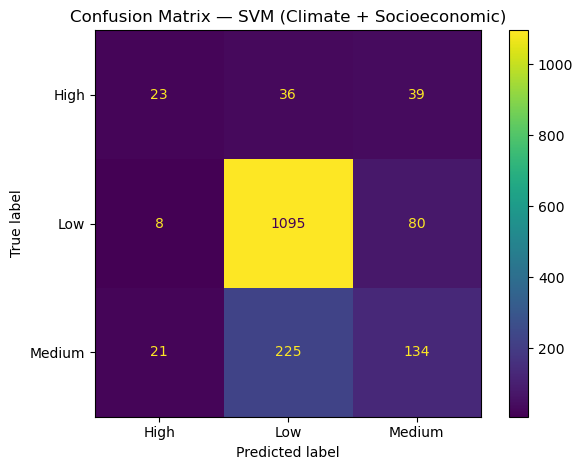

In [12]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = [
    "Rain",
    "Temperature",
    "Relative Humidity"
]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Rain",
    "Temperature",
    "Relative Humidity",
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Climate + Socioeconomic) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Climate + Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model (Climate + Environmental) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7549
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__C': 52.98316906283707}

Hold-out accuracy: 0.7646

Classification report:
              precision    recall  f1-score   support

        High     0.4677    0.2959    0.3625        98
         Low     0.8209    0.9298    0.8720      1183
      Medium     0.5444    0.3711    0.4413       380

    accuracy                         0.7646      1661
   macro avg     0.6110    0.5323    0.5586      1661
weighted avg     0.7368    0.7646    0.7434      1661



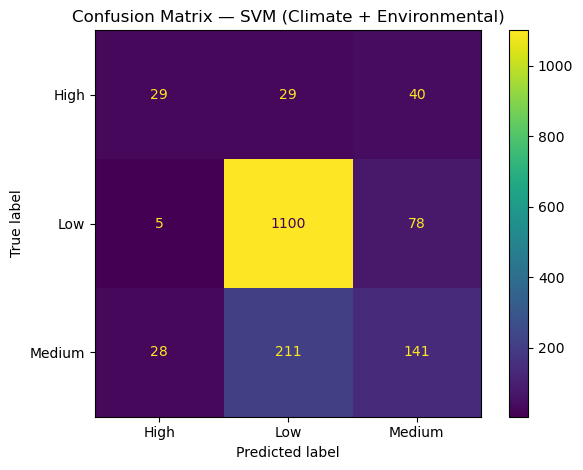

In [14]:
# ============================================================
# FULL MODEL: Climate + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = [
    "Rain",
    "Temperature",
    "Relative Humidity"
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Rain",
    "Temperature",
    "Relative Humidity",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Climate + Environmental) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Climate + Environmental)")
plt.tight_layout()
plt.show()

Full Model (Socioeconomic + Environmental) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 23)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7641
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__C': 100.0}

Hold-out accuracy: 0.7718

Classification report:
              precision    recall  f1-score   support

        High     0.6200    0.3163    0.4189        98
         Low     0.8134    0.9467    0.8750      1183
      Medium     0.5598    0.3447    0.4267       380

    accuracy                         0.7718      1661
   macro avg     0.6644    0.5359    0.5735      1661
weighted avg     0.7440    0.7718    0.7455      1661



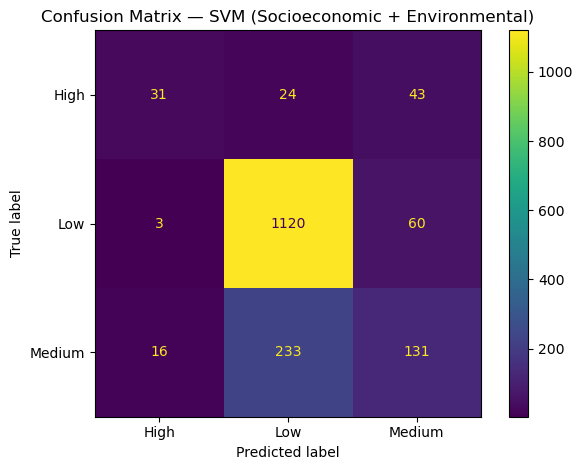

In [16]:
# ============================================================
# FULL MODEL: Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Socioeconomic + Environmental) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()

Full Model (Climate + Socioeconomic + Environmental) — SVM
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 26)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV accuracy: 0.7548
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__C': 52.98316906283707}

Hold-out accuracy: 0.7538

Classification report:
              precision    recall  f1-score   support

        High     0.4390    0.3673    0.4000        98
         Low     0.8277    0.9096    0.8667      1183
      Medium     0.5018    0.3684    0.4249       380

    accuracy                         0.7538      1661
   macro avg     0.5895    0.5484    0.5639      1661
weighted avg     0.7302    0.7538    0.7381      1661



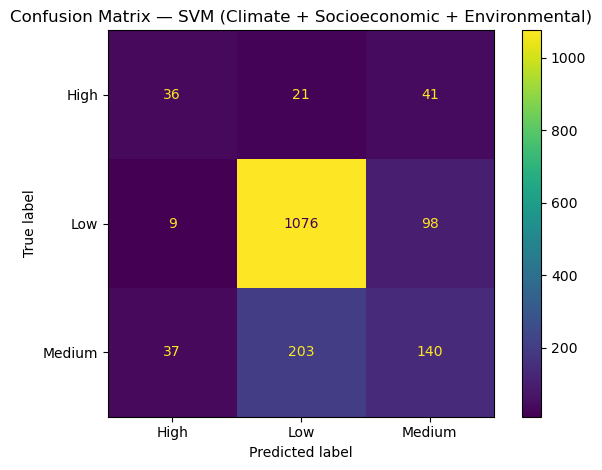

In [18]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = [
    "Rain",
    "Temperature",
    "Relative Humidity"
]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]
LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove leakage variables
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep rows with label + time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Rain",
    "Temperature",
    "Relative Humidity",
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model (Climate + Socioeconomic + Environmental) — SVM")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# SVM (Scaled) + Hyperparameter Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=False, random_state=42))
])

param_dist = {
    "svm__kernel": ["rbf", "linear", "poly"],
    "svm__C": np.logspace(-2, 2, 30),
    "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svm__degree": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — SVM (Climate + Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()